# PU experiments

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from load_experiment import load_experiment_results 
import datetime 
from helpers import get_n_labels


In [ ]:
EXPERIMENT = "label_mechanism"

In [ ]:
df = load_experiment_results(name=EXPERIMENT,n=0)
df = df[df["model"]!="oracle"]
df.columns

In [ ]:
df["precision"] = (df["0 precision"]+df["1 precision"]) / 2
df["recall"] = (df["0 recall"]+df["1 recall"]) / 2
df["f1"] = (df["0 f1"]+df["1 f1"]) / 2

df[["precision","recall","f1"]] = df[["precision","recall","f1"]].round(4)
df[["precision","recall","f1"]].describe()

In [ ]:
fig_experiment_folder = EXPERIMENT
os.makedirs(fig_experiment_folder, exist_ok=True)
current_time = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M")
fig_folder = os.path.join(fig_experiment_folder, f"{current_time}")
os.makedirs(fig_folder, exist_ok=True)

In [ ]:
experiments = df[EXPERIMENT].unique()
experiments = [val for val in experiments if val.split("_")[1] == "1"]
experiments
df_exp = df[df[EXPERIMENT].isin(experiments)]
c_exp = df_exp[[EXPERIMENT,"c log"]].groupby(EXPERIMENT).max().reset_index()
c_exp = c_exp.sort_values(by="c log")
c_exp

In [ ]:


for dataset in df_exp["dataset"].unique():
    assert dataset in ["mock","diabetes","breastcancer","mnist"], f"Unknown dataset: {dataset}"
    values = df_exp[df_exp["dataset"]==dataset][EXPERIMENT].unique()
    def plot_metric(metric="f1",name="Macro F1-score"):
        
        plt.figure(figsize=(10, 6),layout='constrained')
        sns.lineplot(data=df_exp[df_exp["dataset"]==dataset], x=EXPERIMENT,y=metric,marker="o",hue="model")
        plt.title(f"{name} vs SAR assumption for the {dataset} dataset")
        plt.ylabel(name)
        ticks = [f">{val.split('_')[2]}" for val in experiments]
        ticks = ticks[1:]
        ticks.insert(0,"SCAR")
        plt.xticks(experiments, ticks,rotation=45)
        plt.xlabel("Labels have feature value > (%)")
        plt.savefig(os.path.join(fig_folder,f"SAR_{name}_{dataset}.png"))
        plt.show()

    plot_metric(metric="f1",name="Macro F1-score")
    plot_metric(metric="precision",name="Macro Precision")
    plot_metric(metric="recall",name="Macro Recall")
    plot_metric(metric="accuracy",name="Accuracy")



In [ ]:
experiments = df[EXPERIMENT].unique()
experiments = [val for val in experiments if (val.split("_")[0] == "casecontrol") or (val.split("_")[0] == "SCAR")]
experiments = experiments[:2]
df_exp = df[df[EXPERIMENT].isin(experiments)]
df_exp

In [ ]:

for dataset in df_exp["dataset"].unique():
    assert dataset in ["mock","diabetes","breastcancer","mnist"], f"Unknown dataset: {dataset}"
    values = df_exp[df_exp["dataset"]==dataset][EXPERIMENT].unique()

    def plot_metric(metric="f1",name="Macro F1-score"):
        plt.figure(figsize=(10, 6),layout='constrained')
        sns.barplot(data=df_exp[df_exp["dataset"]==dataset], x=EXPERIMENT,y=metric,hue="model")
        plt.title(f"{name} vs SAR assumption for the {dataset} dataset")
        plt.ylabel(name)
        ticks = ["Single train", "Case control"]
        # ticks = ticks[1:]
        # ticks.insert(0,"single train")
        plt.xticks(experiments, ticks,rotation=45)
        plt.xlabel("Labels have feature value > (%)")
        plt.savefig(os.path.join(fig_folder,f"CC_{name}_{dataset}.png"))
        plt.show()
    plot_metric(metric="f1",name="Macro F1-score")
    plot_metric(metric="precision",name="Macro Precision")
    plot_metric(metric="recall",name="Macro Recall")
    plot_metric(metric="accuracy",name="Accuracy")
    
    

In [88]:
df[EXPERIMENT].unique()

array(['SCAR_1_1', 'SAR_1_100', 'SAR_1_250', 'SAR_1_1000', 'SAR_4_5',
       'SAR_4_3', 'SAR_10_5', 'casecontrol_200', 'casecontrol_400',
       'casecontrol_1000'], dtype=object)

In [89]:
experiments = df[EXPERIMENT].unique()
experiments = [val for val in experiments if (int(val.split("_")[1]) > 1 and val.startswith("SAR")) or val.startswith("SCAR")]
experiments
df_exp = df[df[EXPERIMENT].isin(experiments)]
experiments

['SCAR_1_1', 'SAR_4_5', 'SAR_4_3', 'SAR_10_5']

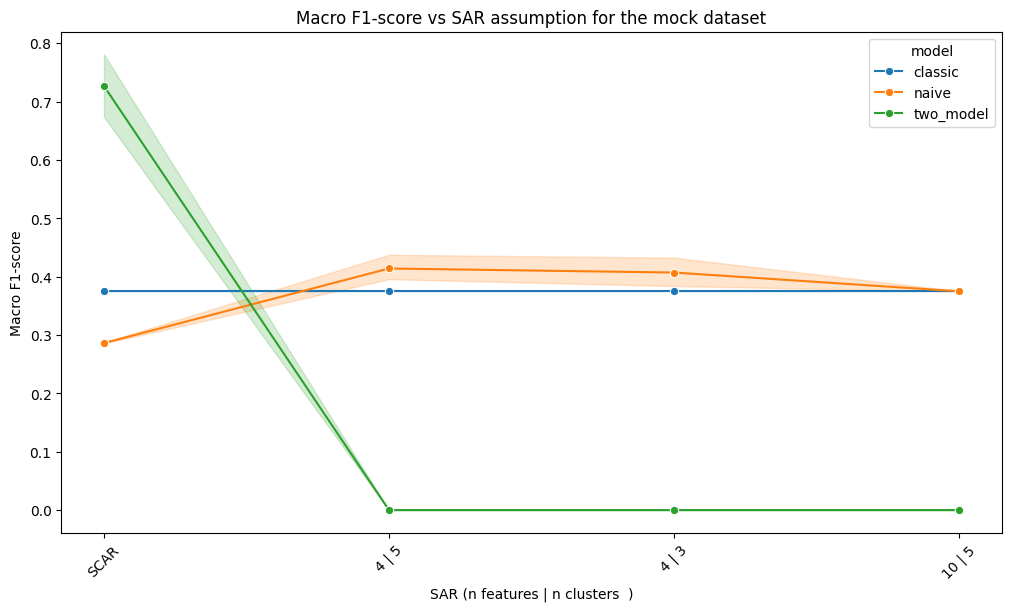

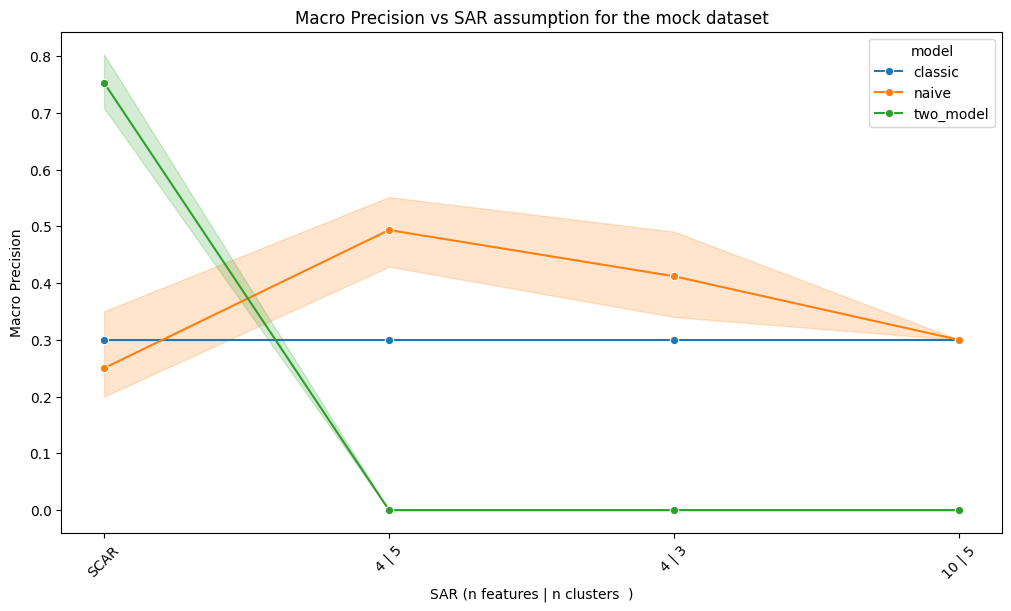

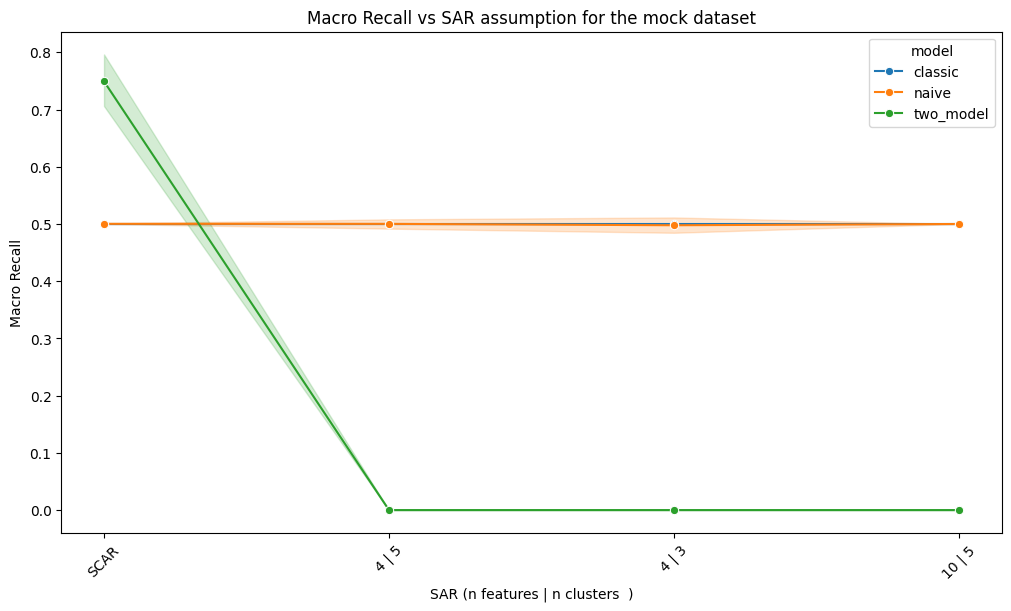

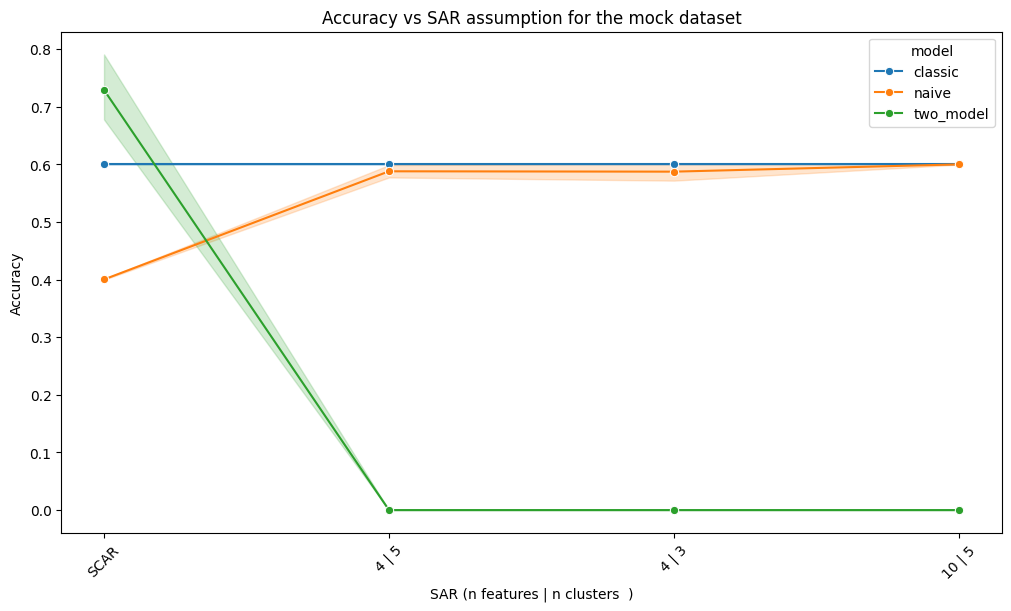

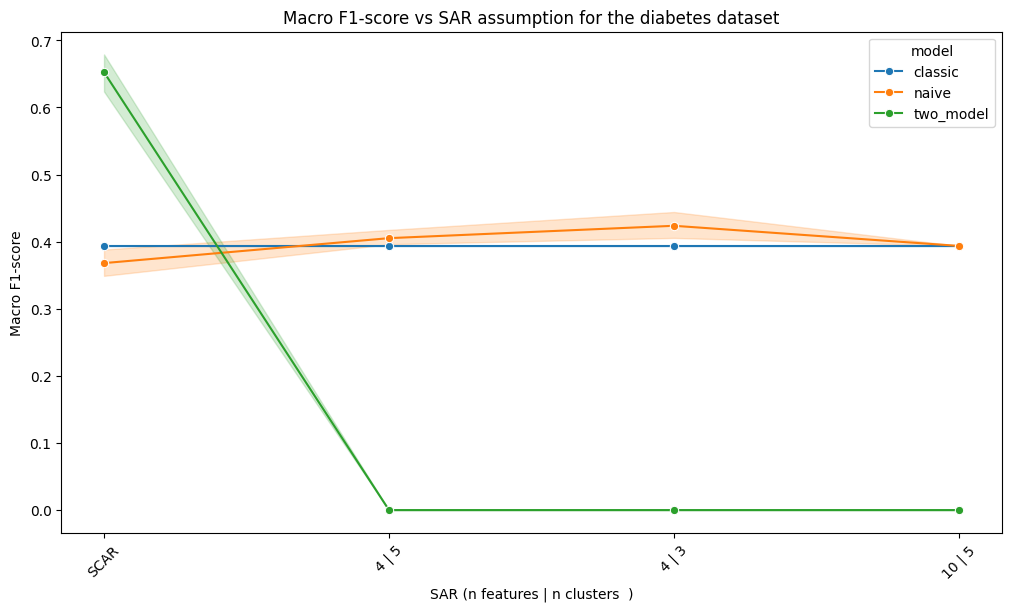

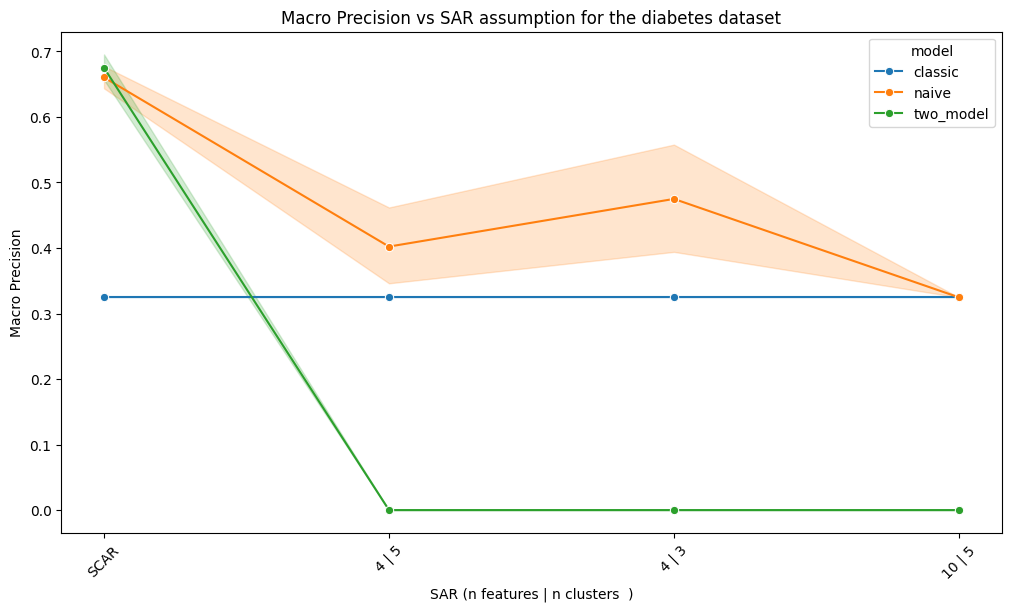

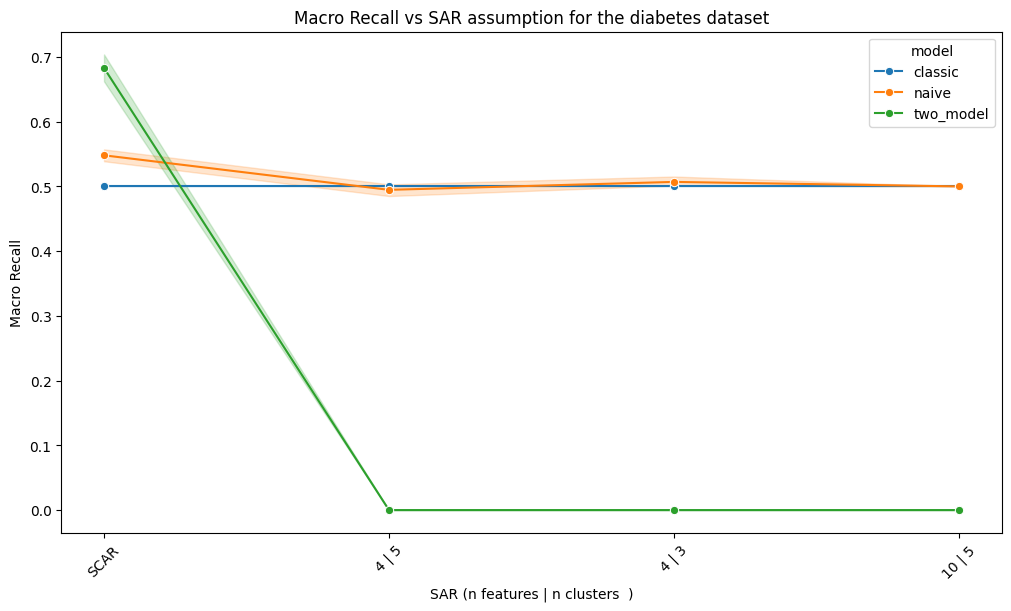

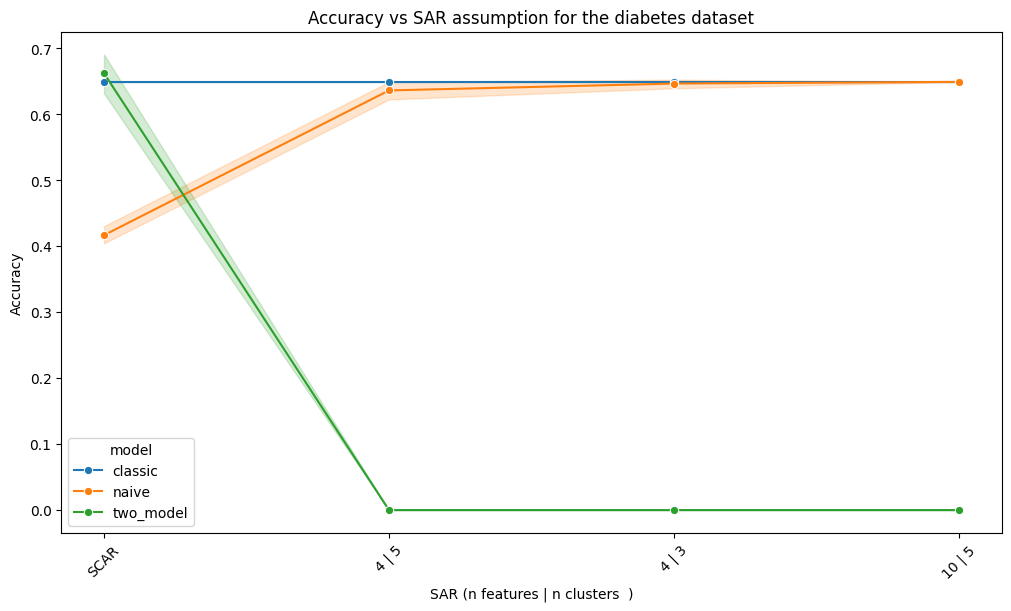

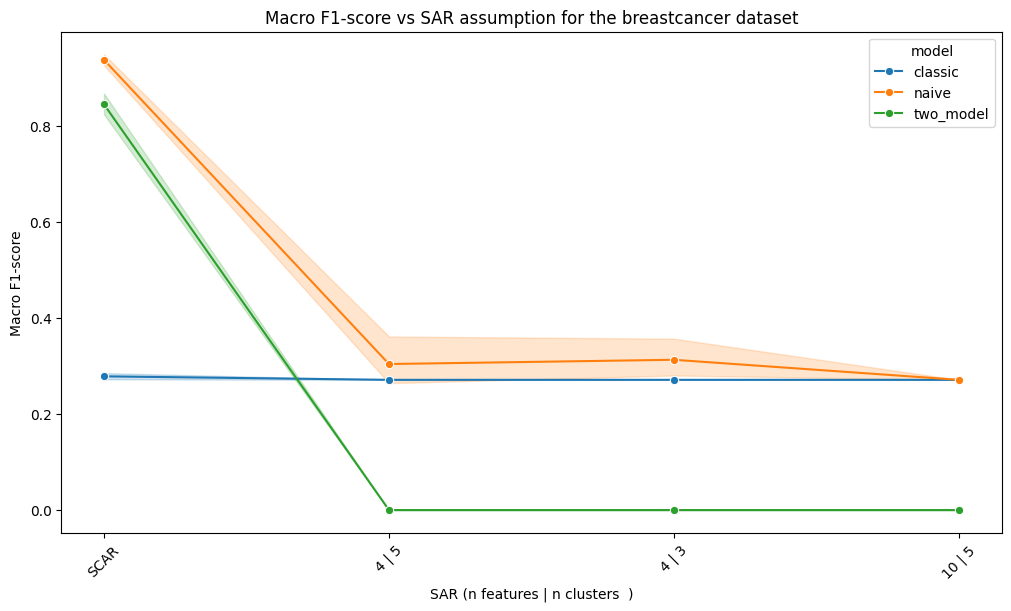

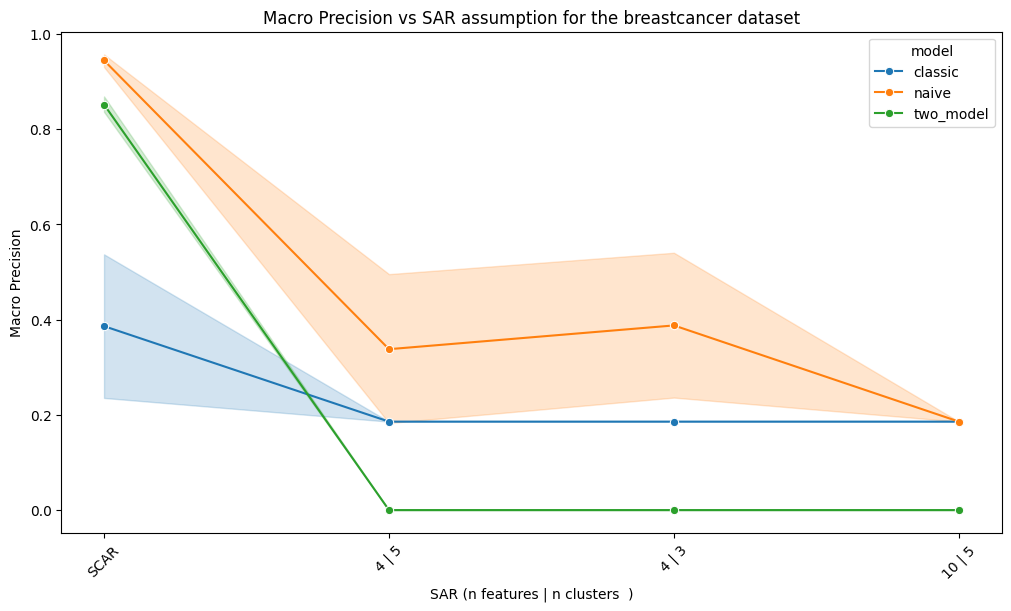

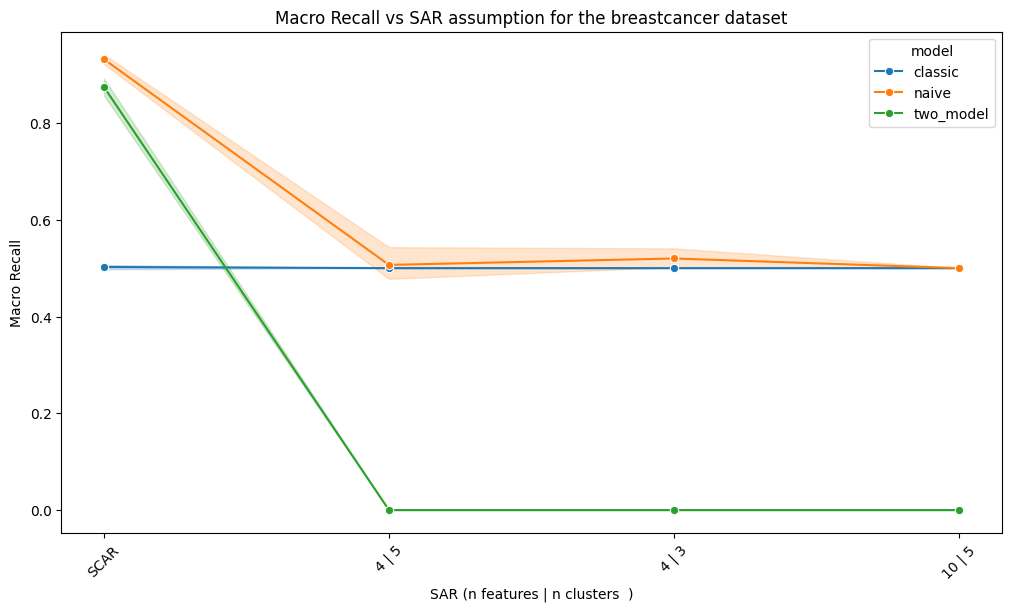

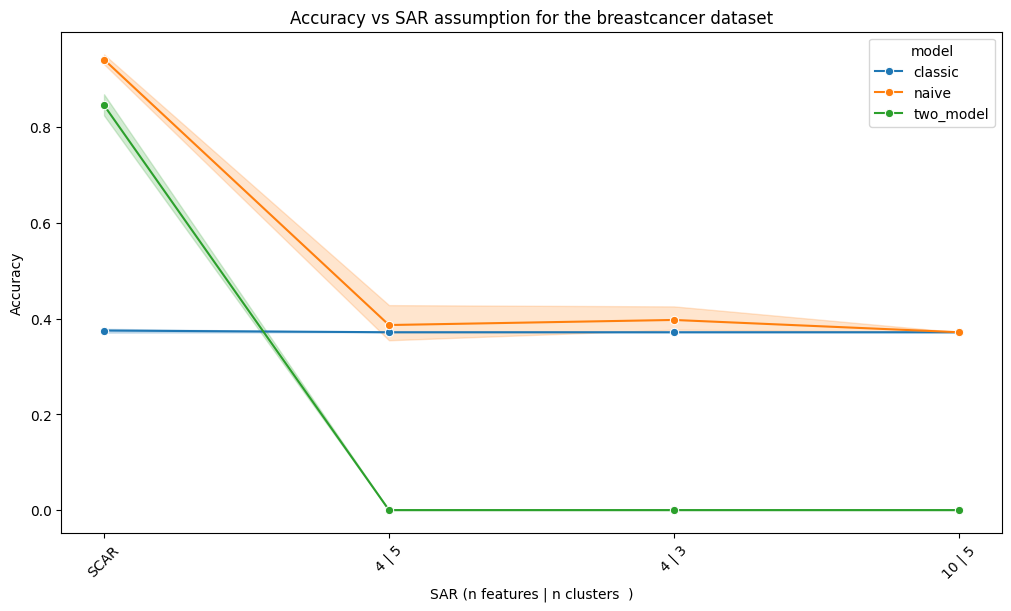

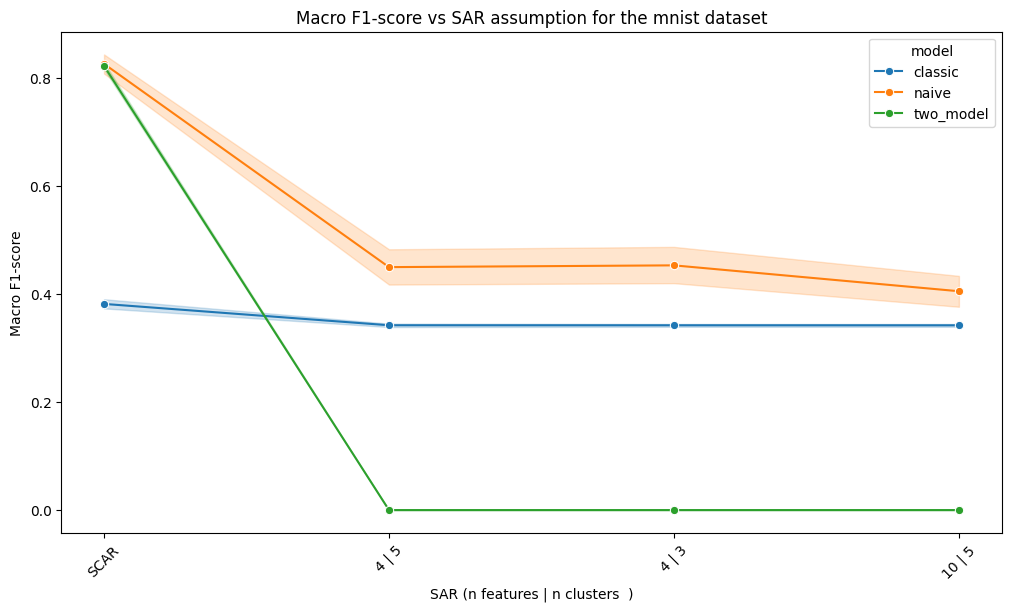

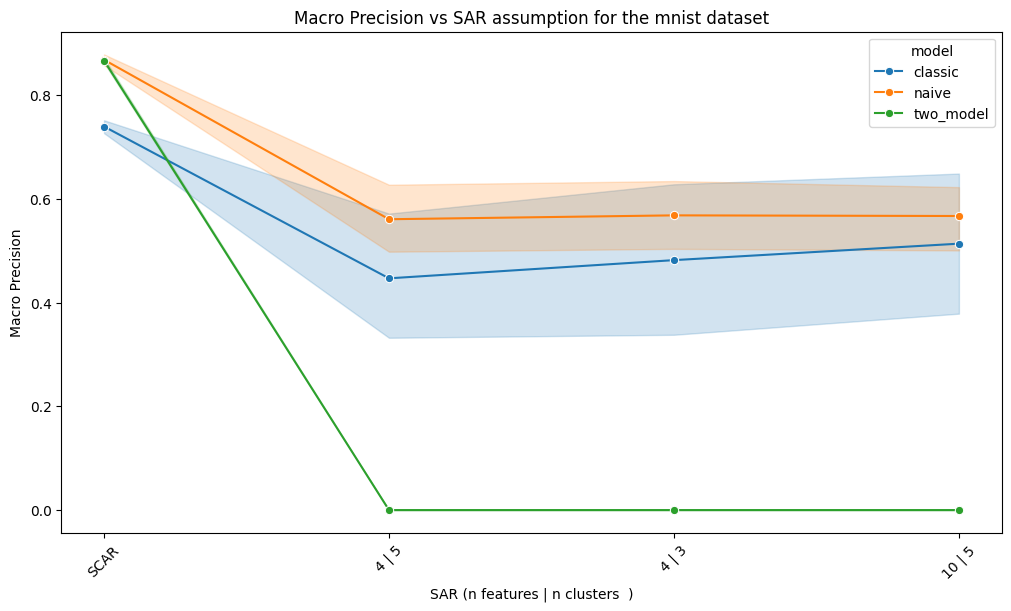

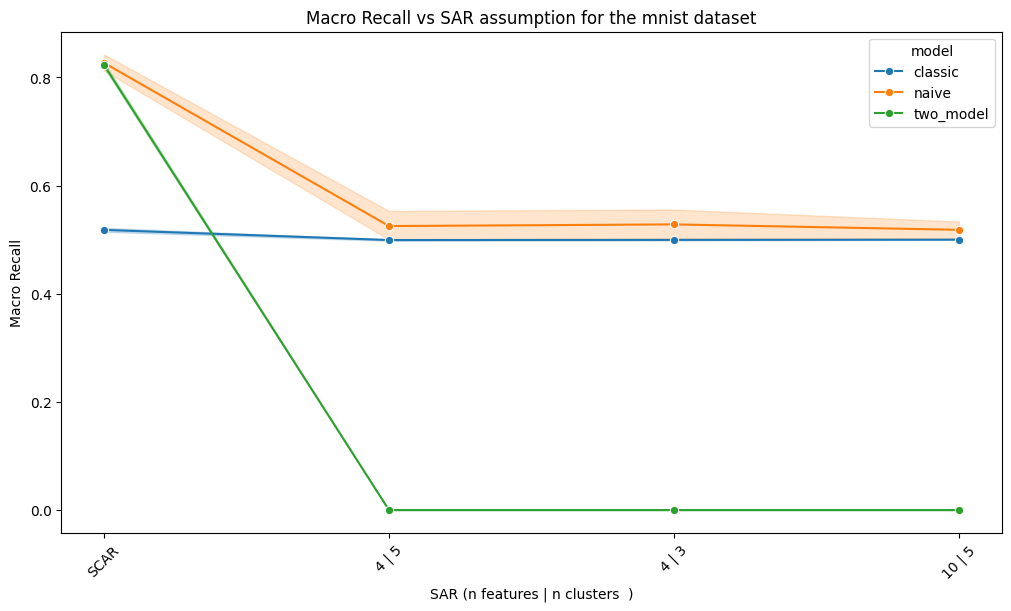

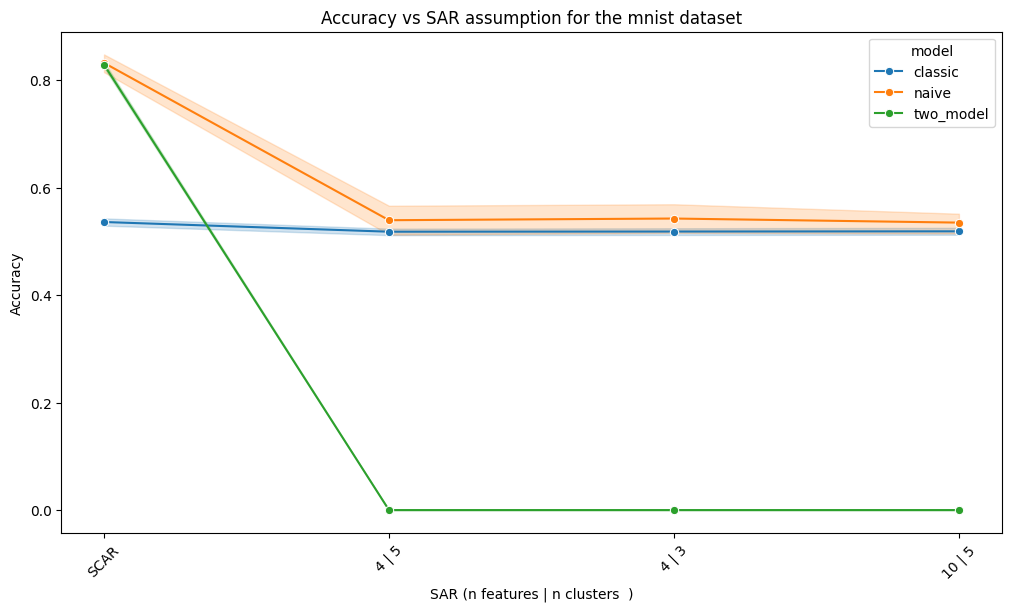

In [91]:
for dataset in df_exp["dataset"].unique():
    assert dataset in ["mock","diabetes","breastcancer","mnist"], f"Unknown dataset: {dataset}"
    values = df_exp[df_exp["dataset"]==dataset][EXPERIMENT].unique()
    def plot_metric(metric="f1",name="Macro F1-score"):
        
        plt.figure(figsize=(10, 6),layout='constrained')
        sns.lineplot(data=df_exp[df_exp["dataset"]==dataset], x=EXPERIMENT,y=metric,marker="o",hue="model")
        plt.title(f"{name} vs SAR assumption for the {dataset} dataset")
        plt.ylabel(name)
        ticks = [f"{val.split('_')[1]} | {val.split('_')[2]}" for val in experiments]
        ticks = ticks[1:]
        ticks.insert(0,"SCAR")
        plt.xticks(experiments, ticks,rotation=45)
        plt.xlabel("SAR (n features | n clusters  )")
        plt.savefig(os.path.join(fig_folder,f"SAR_geo_mean_{name}_{dataset}.png"))
        plt.show()

    plot_metric(metric="f1",name="Macro F1-score")
    plot_metric(metric="precision",name="Macro Precision")
    plot_metric(metric="recall",name="Macro Recall")
    plot_metric(metric="accuracy",name="Accuracy")